# Modeling U.S. Credit Response to Rising Interest Rates 

## Step 1: Imports & Environment Setup

### Imports

In [1]:
import os
import sys
from pathlib import Path
from typing import Dict, Any

import yaml
import logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fredapi import Fred
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

### Verfiy Assets

In [2]:
logger = logging.getLogger("consumer-credit-analysis")

SECRETS_PATH = "../secrets.yaml"

if Path(SECRETS_PATH).exists():
        logger.info("secrets.yaml is properly configured.")
else:
    logger.info('secrets.yaml is not properly configured. Create a secrets.yaml file and add in your FRED API Key. i.e. `FRED_API_KEY:"XXXXXXXXXXXXXXXXXXXXXXX"`')


### Load Secrets File

In [3]:
def _load_yaml_file(path: str, name: str) -> Dict[str, Any]:
    """
    Helper to load any YAML file with a consistent error message.
    """
    abs_path = os.path.abspath(path)
    if not os.path.exists(abs_path):
        raise FileNotFoundError(f"{name} file not found at: {abs_path}")
    with open(abs_path, "r") as f:
        return yaml.safe_load(f) or {}

def load_secrets(secrets_path: str = "secrets.yaml") -> Dict[str, Any]:
    """
    Load application secrets from a YAML file.
    Args:
        secrets_path: Path to the secrets YAML file.

    Returns:
        Secrets dict.

    Raises:
        FileNotFoundError: If the secrets file is not found.
    """
    # If using an external secrets manager, you can create
    # an (empty) secrets.yaml stub in this path to satisfy the loader.
    return _load_yaml_file(secrets_path, "secrets.yaml")

secrets = load_secrets(SECRETS_PATH)
logger.info("Secrets Loaded")

### Setup FRED API Key

In [4]:
api_key = secrets.get("FRED_API_KEY")
fred = Fred(api_key=api_key)
logger.info("FRED API Key Successfully Setup.")

## Step 2: Data Download + Cleaning

In [5]:
# Download data
credit = fred.get_series('TOTALSL')
revolving = fred.get_series('REVOLSL')
nonrev = fred.get_series('NONREVSL')
fedfunds = fred.get_series('FEDFUNDS')
lending = fred.get_series('DRCCLACBS')


# Combine
df = pd.DataFrame({
    'credit_total': credit,
    'revolving': revolving,
    'nonrevolving': nonrev,
    'fedfunds': fedfunds,
    'lending_std': lending
})

df = df.dropna()
logger.info("Datasets loaded and cleaned.")

## Step 3: Exploratory Data Analysis (EDA)

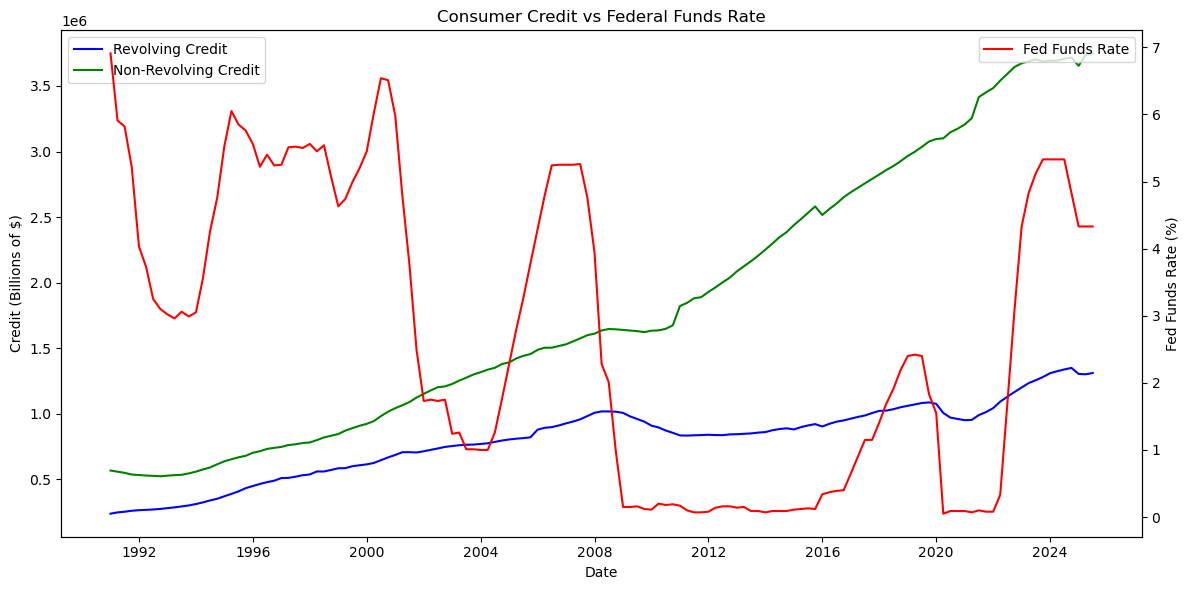

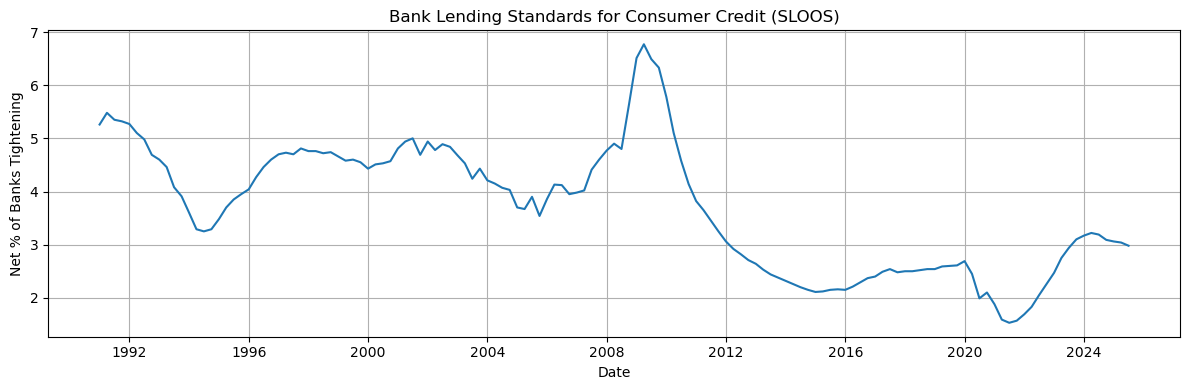

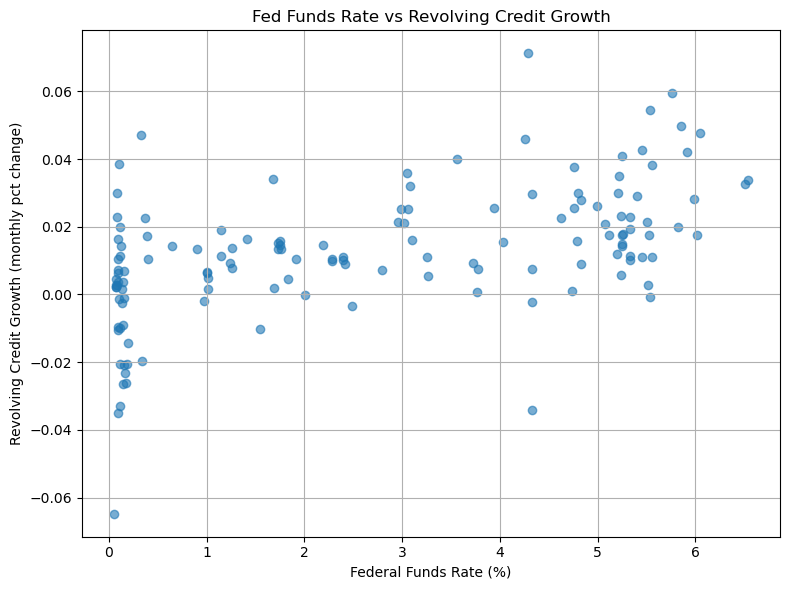

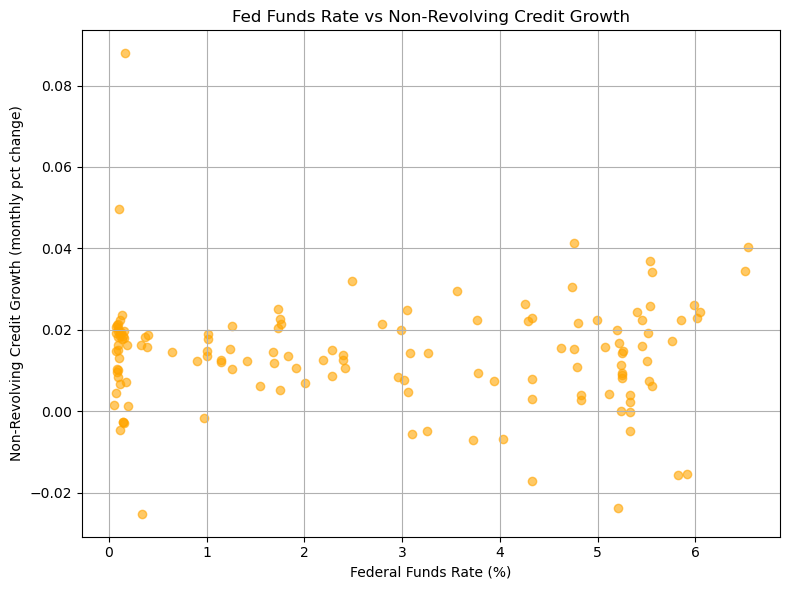

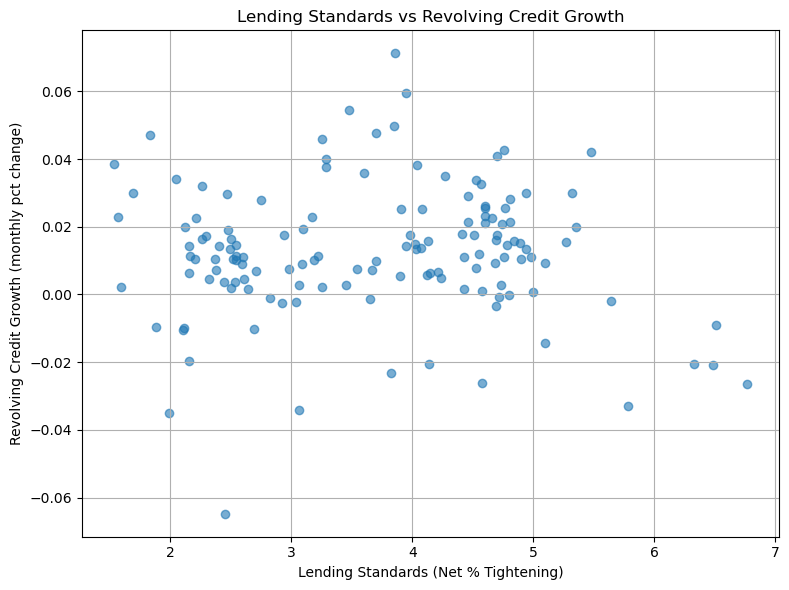

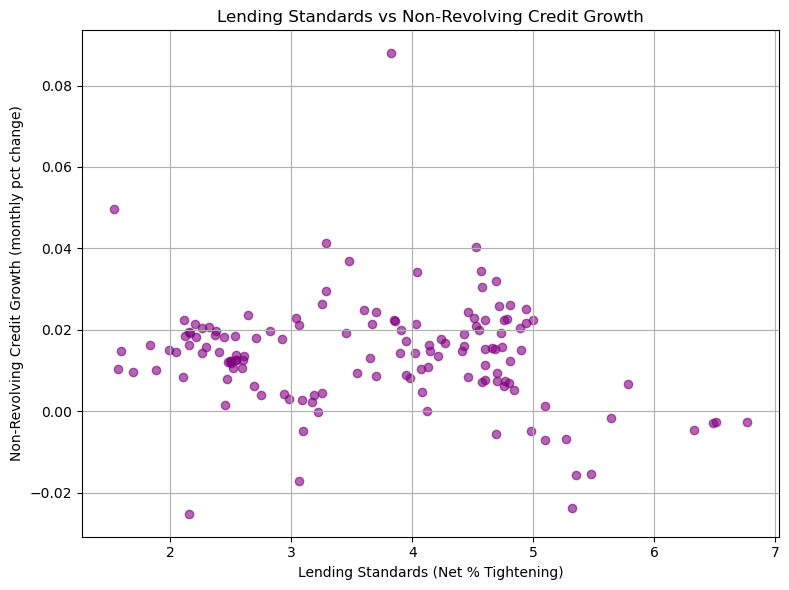

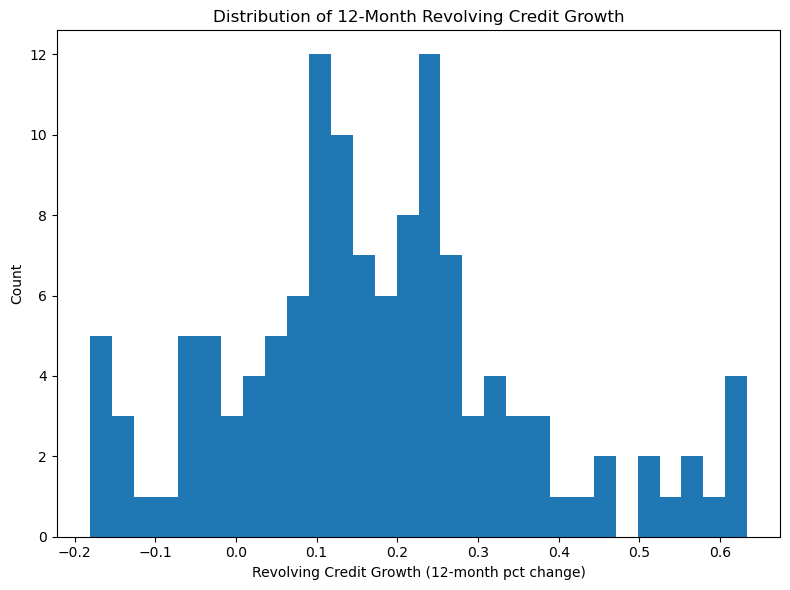

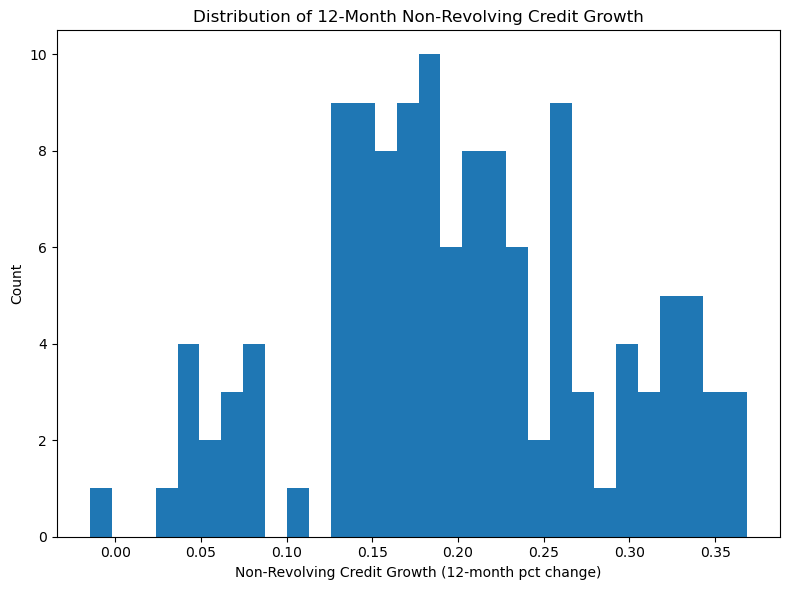

In [6]:
# --- Growth rate calculations ---
df['revolving_growth'] = df['revolving'].pct_change()
df['nonrev_growth'] = df['nonrevolving'].pct_change()

df["revolving_growth_12m"] = df["revolving"].pct_change(12)
df["nonrev_growth_12m"] = df["nonrevolving"].pct_change(12)

# ---------------------------------------------------------------
# TIME-SERIES PLOT with dual y-axes (so fed funds is visible)
# ---------------------------------------------------------------
# 1) Credit vs Fed Funds
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df.index, df["revolving"], label="Revolving Credit", color="blue")
ax1.plot(df.index, df["nonrevolving"], label="Non-Revolving Credit", color="green")
ax1.set_xlabel("Date")
ax1.set_ylabel("Credit (Billions of $)")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(df.index, df["fedfunds"], label="Fed Funds Rate", color="red")
ax2.set_ylabel("Fed Funds Rate (%)")
ax2.legend(loc="upper right")

plt.title("Consumer Credit vs Federal Funds Rate")
plt.tight_layout()
plt.show()

# 2) Lending Standards over time
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["lending_std"], label="Lending Standards (SLOOS)")
plt.xlabel("Date")
plt.ylabel("Net % of Banks Tightening")
plt.title("Bank Lending Standards for Consumer Credit (SLOOS)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# SCATTER PLOTS (Cleaned for NaNs)
# ---------------------------------------------------------------
df_scatter = df[
    ["fedfunds", "lending_std", "revolving_growth", "nonrev_growth"]
].dropna()

# Fed Funds vs Revolving growth
plt.figure(figsize=(8, 6))
plt.scatter(df_scatter["fedfunds"], df_scatter["revolving_growth"], alpha=0.6)
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Revolving Credit Growth (monthly pct change)")
plt.title("Fed Funds Rate vs Revolving Credit Growth")
plt.grid(True)
plt.tight_layout()
plt.show()

# Fed Funds vs Non-Revolving growth
plt.figure(figsize=(8, 6))
plt.scatter(df_scatter["fedfunds"], df_scatter["nonrev_growth"], alpha=0.6, color="orange")
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Non-Revolving Credit Growth (monthly pct change)")
plt.title("Fed Funds Rate vs Non-Revolving Credit Growth")
plt.grid(True)
plt.tight_layout()
plt.show()

# Lending standards vs Revolving growth
plt.figure(figsize=(8, 6))
plt.scatter(df_scatter["lending_std"], df_scatter["revolving_growth"], alpha=0.6)
plt.xlabel("Lending Standards (Net % Tightening)")
plt.ylabel("Revolving Credit Growth (monthly pct change)")
plt.title("Lending Standards vs Revolving Credit Growth")
plt.grid(True)
plt.tight_layout()
plt.show()

# Lending standards vs Non-Revolving growth
plt.figure(figsize=(8, 6))
plt.scatter(df_scatter["lending_std"], df_scatter["nonrev_growth"], alpha=0.6, color="purple")
plt.xlabel("Lending Standards (Net % Tightening)")
plt.ylabel("Non-Revolving Credit Growth (monthly pct change)")
plt.title("Lending Standards vs Non-Revolving Credit Growth")
plt.grid(True)
plt.tight_layout()
plt.show()

# Histogram for 12‑month growth (Revolving)
plt.figure(figsize=(8, 6))
plt.hist(df["revolving_growth_12m"].dropna(), bins=30)
plt.xlabel("Revolving Credit Growth (12‑month pct change)")
plt.ylabel("Count")
plt.title("Distribution of 12‑Month Revolving Credit Growth")
plt.tight_layout()
plt.show()

# Histogram for 12‑month growth (Non-Revolving)
plt.figure(figsize=(8, 6))
plt.hist(df["nonrev_growth_12m"].dropna(), bins=30)
plt.xlabel("Non-Revolving Credit Growth (12‑month pct change)")
plt.ylabel("Count")
plt.title("Distribution of 12‑Month Non-Revolving Credit Growth")
plt.tight_layout()
plt.show()


## Step 4: Modeling

### Setup & Helper Functions

In [7]:
for lag in [0, 3, 6, 12]:
    df[f"fedfunds_lag{lag}"] = df["fedfunds"].shift(lag)
    df[f"lending_std_lag{lag}"] = df["lending_std"].shift(lag)

df_model = df[
    [
        "revolving_growth_12m",
        "nonrev_growth_12m",
        "fedfunds_lag0",
        "fedfunds_lag3",
        "fedfunds_lag6",
        "fedfunds_lag12",
        "lending_std_lag0",
        "lending_std_lag3",
        "lending_std_lag6",
        "lending_std_lag12",
    ]
].dropna()

print("\nModel dataframe shape:", df_model.shape)
display(df_model.head())

features_rate = ["fedfunds_lag0", "fedfunds_lag3", "fedfunds_lag6", "fedfunds_lag12"]
features_rate_lend = features_rate + [
    "lending_std_lag0",
    "lending_std_lag3",
    "lending_std_lag6",
    "lending_std_lag12",
]

print("Columns in df_model:", df_model.columns.tolist())
print("Fed Funds feature set:", features_rate)
print("Fed Funds + Lending feature set:", features_rate_lend)

# Convenience targets
y_rev = df_model["revolving_growth_12m"]
y_nonrev = df_model["nonrev_growth_12m"]


Model dataframe shape: (127, 10)


,revolving_growth_12m,nonrev_growth_12m,fedfunds_lag0,fedfunds_lag3,fedfunds_lag6,fedfunds_lag12,lending_std_lag0,lending_std_lag3,lending_std_lag6,lending_std_lag12
1994-01-01,0.309184,-0.014766,3.05,2.96,3.25,6.91,3.60,4.46,4.98,5.26
1994-04-01,0.306628,0.030226,3.56,3.06,3.10,5.91,3.29,4.08,4.69,5.48
1994-07-01,0.339844,0.074289,4.26,2.99,3.02,5.82,3.25,3.91,4.60,5.35
1994-10-01,0.349843,0.145962,4.76,3.05,2.96,5.21,3.29,3.60,4.46,5.32
1995-01-01,0.401741,0.196395,5.53,3.56,3.06,4.03,3.48,3.29,4.08,5.27


Columns in df_model: ['revolving_growth_12m', 'nonrev_growth_12m', 'fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12', 'lending_std_lag0', 'lending_std_lag3', 'lending_std_lag6', 'lending_std_lag12']
Fed Funds feature set: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
Fed Funds + Lending feature set: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12', 'lending_std_lag0', 'lending_std_lag3', 'lending_std_lag6', 'lending_std_lag12']


In [8]:
# ---------------------------------------------------------------
# Helper function – time-series train/test, metrics, optional plot
# ---------------------------------------------------------------
def run_time_series_model(
    X: pd.DataFrame,
    y: pd.Series,
    estimator,
    model_name: str,
    target_label: str,
    test_size: float = 0.2,
    plot: bool = False,
):
    """
    Train/test split without shuffling (respect time order),
    fit the model, compute R^2 and RMSE, optionally plot.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    model = estimator.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n=== {model_name} ===")
    print(f"Target: {target_label}")
    print(f"Features: {list(X.columns)}")
    print(f"R^2 (test): {r2:.3f}")
    print(f"RMSE (test): {rmse:.4f}")

    # Coefficients for linear regression
    if hasattr(model, "coef_"):
        print("Coefficients:")
        for name, coef in zip(X.columns, model.coef_):
            print(f"  {name}: {coef:.4f}")
        print(f"Intercept: {model.intercept_:.4f}")

    # Feature importances for Random Forest
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=X.columns)
        print("\nFeature importances:")
        display(importances.sort_values(ascending=False))

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(y_test.index, y_test, label="Actual", linewidth=1.5)
        plt.plot(
            y_test.index,
            y_pred,
            label="Predicted",
            linestyle="--",
            linewidth=1.5,
        )
        plt.xlabel("Date")
        plt.ylabel(target_label)
        plt.title(model_name + " - Actual vs Predicted")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        "model_name": model_name,
        "target": target_label,
        "features": list(X.columns),
        "r2": r2,
        "rmse": rmse,
    }, y_test, y_pred, model

results = []

### Fed Funds Only (Baseline)


=== Random Forest - Revolving 12m Growth (Fed Funds Only) ===
Target: Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
R^2 (test): 0.768
RMSE (test): 0.0705

Feature importances:


fedfunds_lag3     0.580522
fedfunds_lag0     0.167716
fedfunds_lag6     0.149505
fedfunds_lag12    0.102257
dtype: float64

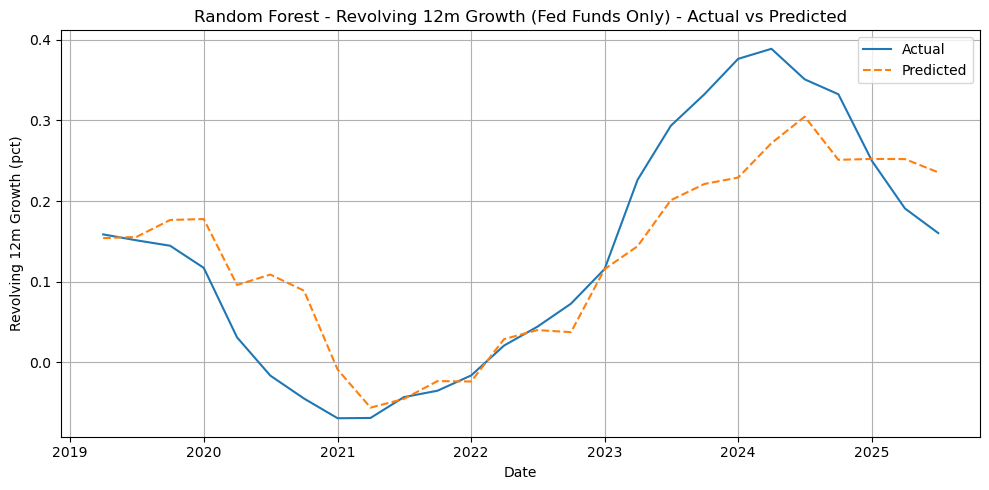

In [9]:
X_rev_rate = df_model[features_rate]

# 1) RF – Revolving 12m Growth (Fed Funds only)
rf_rev = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=3,
)
res1, y1_test, y1_pred, rf_rev_fit = run_time_series_model(
    X_rev_rate,
    y_rev,
    rf_rev,
    "Random Forest - Revolving 12m Growth (Fed Funds Only)",
    "Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res1)

### Model 1a: Linear Regression for revolving credit growth (12month)
Question: Do higher interest rates reduce revolving credit growth?


=== LR - Revolving 12m Growth (Fed Funds) ===
Target: Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
R^2 (test): 0.648
RMSE (test): 0.0869
Coefficients:
  fedfunds_lag0: 0.0477
  fedfunds_lag3: -0.0030
  fedfunds_lag6: 0.0379
  fedfunds_lag12: -0.0085
Intercept: -0.0079


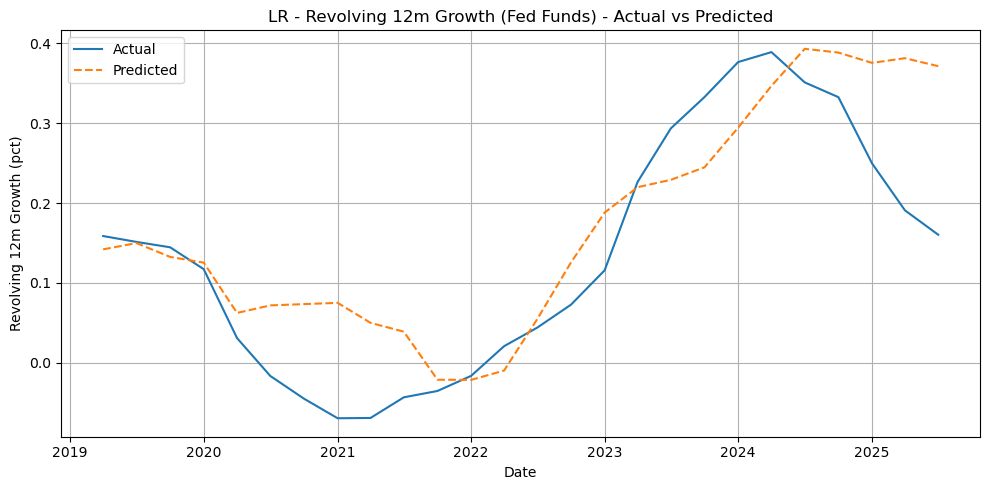

In [10]:
X_rev = df_model[features_rate]
y_rev = df_model["revolving_growth_12m"]

res2, y2_test, y2_pred, lr_rev = run_time_series_model(
    X_rev,
    y_rev,
    LinearRegression(),
    "LR - Revolving 12m Growth (Fed Funds)",
    "Revolving 12m Growth (pct)",
    plot=True,  # keep a nice plot for this one
)
results.append(res2)


### Model 1b: Random Forest for revolving credit growth (12month)


=== Random Forest – Revolving 12m Growth (Fed Funds) ===
Target: Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
R^2 (test): 0.768
RMSE (test): 0.0705

Feature importances:


fedfunds_lag3     0.580522
fedfunds_lag0     0.167716
fedfunds_lag6     0.149505
fedfunds_lag12    0.102257
dtype: float64

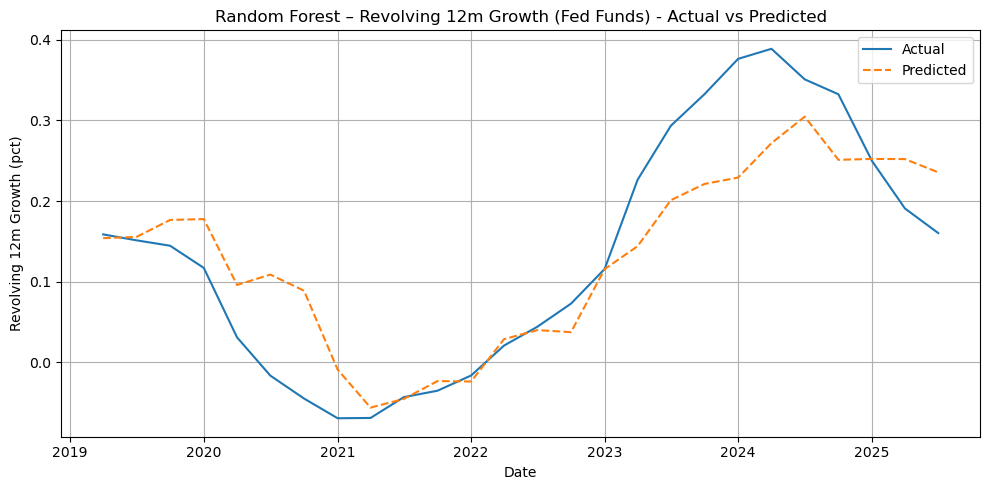

In [11]:
rf_rev = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=3,
)

res3, y3_test, y3_pred, rf_rev_fit = run_time_series_model(
    X_rev,
    y_rev,
    rf_rev,
    "Random Forest – Revolving 12m Growth (Fed Funds)",
    "Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res3)


### Model 2a: Linear Regression for non-revolving credit growth
Question: Is non-revolving credit less sensitive to rate changes?


=== LR - Non-Revolving 12m Growth (Fed Funds Only) ===
Target: Non-Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
R^2 (test): -6.019
RMSE (test): 0.1164
Coefficients:
  fedfunds_lag0: -0.0049
  fedfunds_lag3: 0.0119
  fedfunds_lag6: 0.0106
  fedfunds_lag12: -0.0104
Intercept: 0.2013


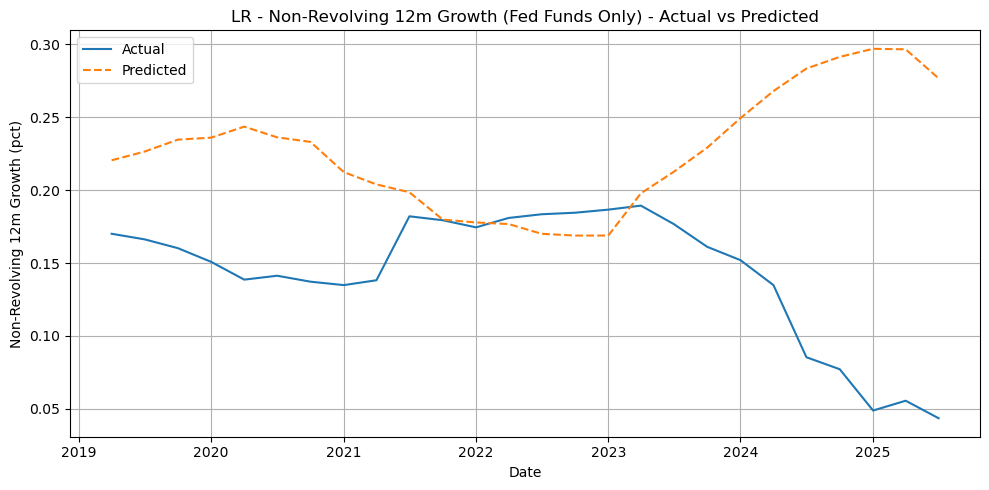

In [12]:
y_nonrev = df_model["nonrev_growth_12m"]

res4, y4_test, y4_pred, lr_nonrev = run_time_series_model(
    X_rev,  # same features: Fed Funds lags
    y_nonrev,
    LinearRegression(),
    "LR - Non-Revolving 12m Growth (Fed Funds Only)",
    "Non-Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res4)

### Model 2b: Random Forest for non-revolving credit growth


=== Random Forest – Non-Revolving 12m Growth (Fed Funds Only) ===
Target: Non-Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12']
R^2 (test): -1.068
RMSE (test): 0.0632

Feature importances:


fedfunds_lag6     0.306490
fedfunds_lag3     0.255311
fedfunds_lag12    0.240832
fedfunds_lag0     0.197367
dtype: float64

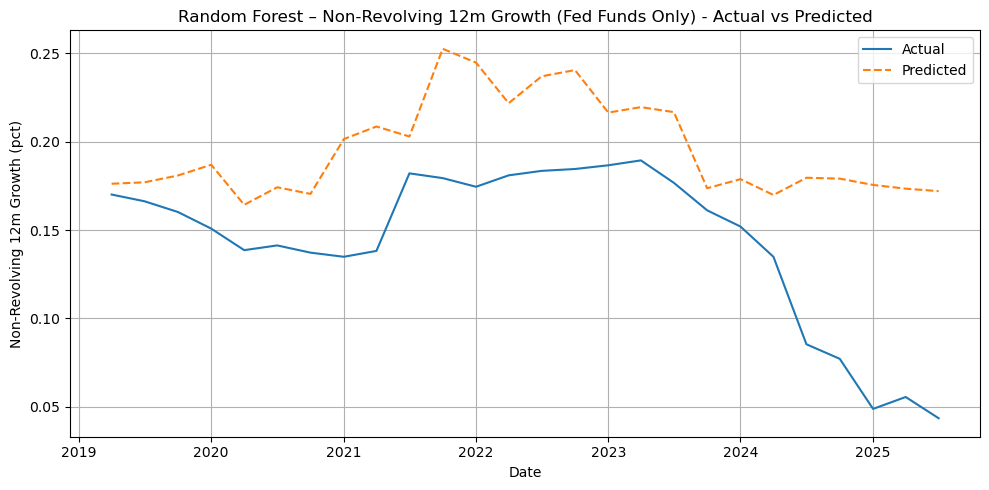

In [13]:
rf_nonrev = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=3,
)

res5, y5_test, y5_pred, rf_nonrev_fit = run_time_series_model(
    X_rev,
    y_nonrev,
    rf_nonrev,
    "Random Forest – Non-Revolving 12m Growth (Fed Funds Only)",
    "Non-Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res5)


=== Linear Regression – Revolving 12m Growth (Fed Funds + Lending Standards) ===
Target: Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12', 'lending_std_lag0', 'lending_std_lag3', 'lending_std_lag6', 'lending_std_lag12']
R^2 (test): -0.196
RMSE (test): 0.1602
Coefficients:
  fedfunds_lag0: 0.0439
  fedfunds_lag3: -0.0006
  fedfunds_lag6: 0.0247
  fedfunds_lag12: 0.0358
  lending_std_lag0: 0.0029
  lending_std_lag3: -0.0050
  lending_std_lag6: -0.0967
  lending_std_lag12: -0.0059
Intercept: 0.3198


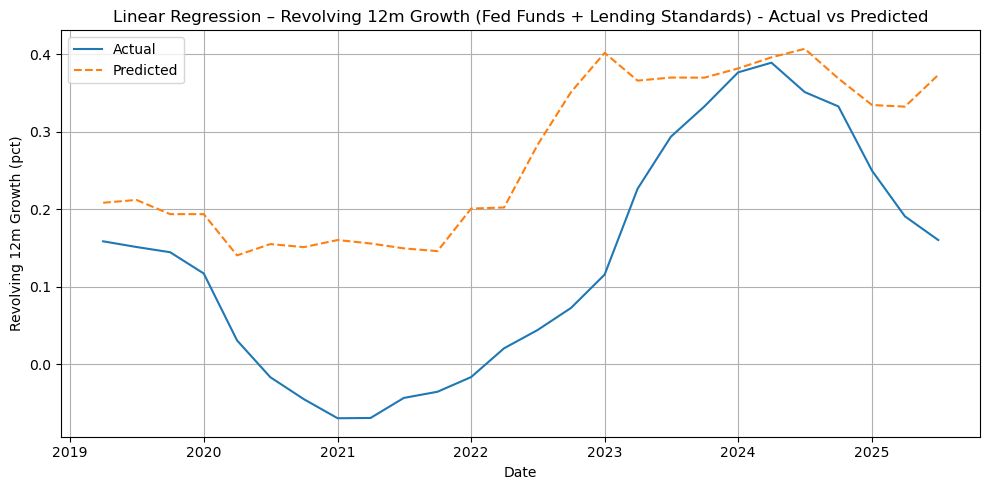


=== Random Forest – Revolving 12m Growth (Fed Funds + Lending Standards) ===
Target: Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12', 'lending_std_lag0', 'lending_std_lag3', 'lending_std_lag6', 'lending_std_lag12']
R^2 (test): 0.227
RMSE (test): 0.1288

Feature importances:


fedfunds_lag3        0.523356
fedfunds_lag6        0.123169
lending_std_lag6     0.106486
fedfunds_lag0        0.104863
lending_std_lag12    0.093636
fedfunds_lag12       0.023249
lending_std_lag3     0.015408
lending_std_lag0     0.009833
dtype: float64

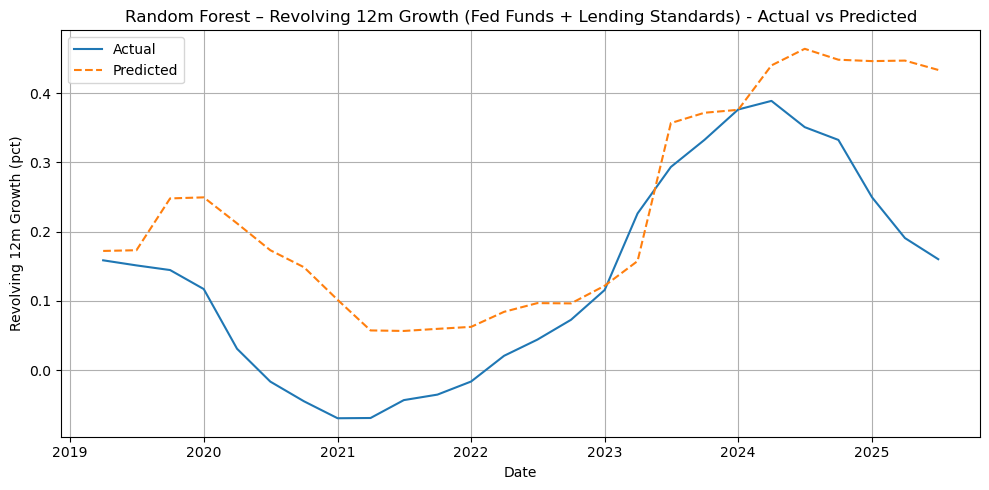


=== Linear Regression – Non-Revolving 12m Growth (Fed Funds + Lending Standards) ===
Target: Non-Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12', 'lending_std_lag0', 'lending_std_lag3', 'lending_std_lag6', 'lending_std_lag12']
R^2 (test): -5.603
RMSE (test): 0.1129
Coefficients:
  fedfunds_lag0: -0.0100
  fedfunds_lag3: 0.0077
  fedfunds_lag6: 0.0231
  fedfunds_lag12: 0.0066
  lending_std_lag0: -0.0292
  lending_std_lag3: -0.0050
  lending_std_lag6: -0.0369
  lending_std_lag12: 0.0297
Intercept: 0.2990


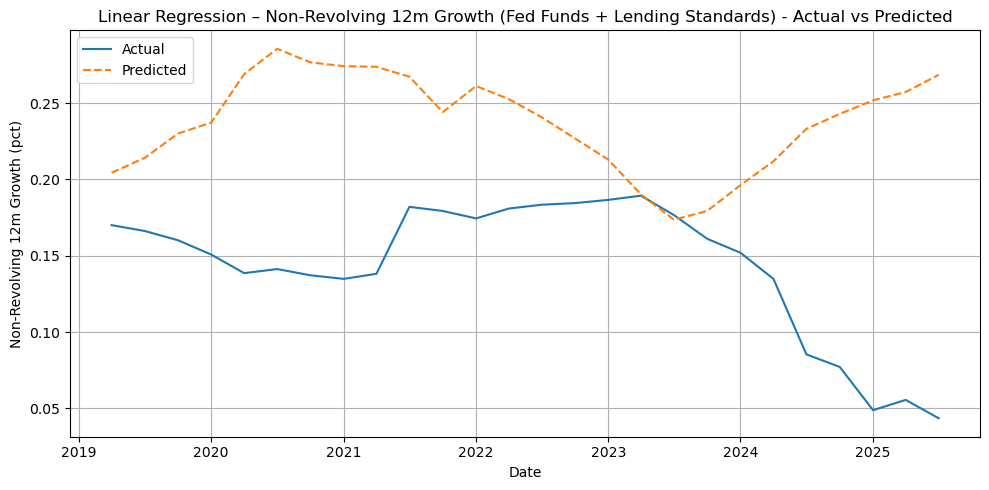


=== Random Forest – Non-Revolving 12m Growth (Fed Funds + Lending Standards) ===
Target: Non-Revolving 12m Growth (pct)
Features: ['fedfunds_lag0', 'fedfunds_lag3', 'fedfunds_lag6', 'fedfunds_lag12', 'lending_std_lag0', 'lending_std_lag3', 'lending_std_lag6', 'lending_std_lag12']
R^2 (test): -1.348
RMSE (test): 0.0673

Feature importances:


lending_std_lag3     0.198041
fedfunds_lag3        0.162673
fedfunds_lag6        0.160448
lending_std_lag0     0.128700
lending_std_lag6     0.100842
lending_std_lag12    0.095082
fedfunds_lag12       0.077319
fedfunds_lag0        0.076895
dtype: float64

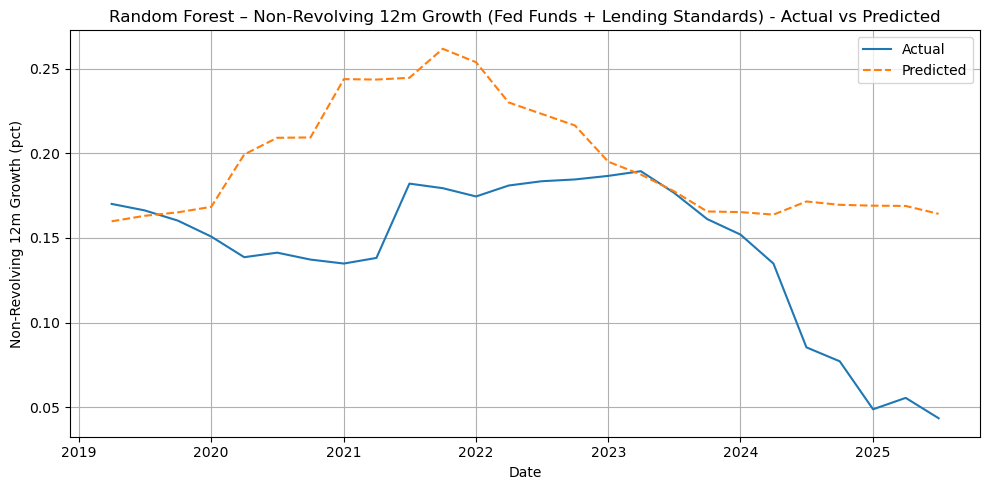

In [14]:
X_policy = df_model[features_rate_lend]

# 4) LR – Revolving 12m Growth (Fed Funds + Lending)
res6, y6_test, y6_pred, lr_rev_policy = run_time_series_model(
    X_policy,
    y_rev,
    LinearRegression(),
    "Linear Regression – Revolving 12m Growth (Fed Funds + Lending Standards)",
    "Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res6)

# 5) RF – Revolving 12m Growth (Fed Funds + Lending)
rf_rev_policy = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=3,
)
res7, y7_test, y7_pred, rf_rev_policy_fit = run_time_series_model(
    X_policy,
    y_rev,
    rf_rev_policy,
    "Random Forest – Revolving 12m Growth (Fed Funds + Lending Standards)",
    "Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res7)

# 6) LR – Non-Revolving 12m Growth (Fed Funds + Lending)
res8, y8_test, y8_pred, lr_nonrev_policy = run_time_series_model(
    X_policy,
    y_nonrev,
    LinearRegression(),
    "Linear Regression – Non-Revolving 12m Growth (Fed Funds + Lending Standards)",
    "Non-Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res8)

# 7) RF – Non-Revolving 12m Growth (Fed Funds + Lending)
rf_nonrev_policy = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=3,
)
res9, y9_test, y9_pred, rf_nonrev_policy_fit = run_time_series_model(
    X_policy,
    y_nonrev,
    rf_nonrev_policy,
    "Random Forest – Non-Revolving 12m Growth (Fed Funds + Lending Standards)",
    "Non-Revolving 12m Growth (pct)",
    plot=True,
)
results.append(res9)

In [15]:
results_df = pd.DataFrame(results)
display(results_df)

,model_name,target,features,r2,rmse
0,Random Forest - Revolving 12m Growth (Fed Fund...,Revolving 12m Growth (pct),"[fedfunds_lag0, fedfunds_lag3, fedfunds_lag6, ...",0.768367,0.070475
1,LR - Revolving 12m Growth (Fed Funds),Revolving 12m Growth (pct),"[fedfunds_lag0, fedfunds_lag3, fedfunds_lag6, ...",0.647962,0.086882
2,Random Forest – Revolving 12m Growth (Fed Funds),Revolving 12m Growth (pct),"[fedfunds_lag0, fedfunds_lag3, fedfunds_lag6, ...",0.768367,0.070475
3,LR - Non-Revolving 12m Growth (Fed Funds Only),Non-Revolving 12m Growth (pct),"[fedfunds_lag0, fedfunds_lag3, fedfunds_lag6, ...",-6.018956,0.116391
4,Random Forest – Non-Revolving 12m Growth (Fed ...,Non-Revolving 12m Growth (pct),"[fedfunds_lag0, fedfunds_lag3, fedfunds_lag6, ...",-1.067833,0.063175
5,Linear Regression – Revolving 12m Growth (Fed ...,Revolving 12m Growth (pct),"[fedfunds_lag0, fedfunds_lag3, fedfunds_lag6, ...",-0.196373,0.160165
6,Random Forest – Revolving 12m Growth (Fed Fund...,Revolving 12m Growth (pct),"[fedfunds_lag0, fedfunds_lag3, fedfunds_lag6, ...",0.226869,0.128754
7,Linear Regression – Non-Revolving 12m Growth (...,Non-Revolving 12m Growth (pct),"[fedfunds_lag0, fedfunds_lag3, fedfunds_lag6, ...",-5.602801,0.112888
8,Random Forest – Non-Revolving 12m Growth (Fed ...,Non-Revolving 12m Growth (pct),"[fedfunds_lag0, fedfunds_lag3, fedfunds_lag6, ...",-1.348354,0.067323
